In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
expenses = pd.read_csv('Daily Household Transactions.csv')

In [4]:
expenses

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
...,...,...,...,...,...,...,...,...
2456,1/1/2015,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,1/1/2015,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,1/1/2015,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,1/1/2015,Cash,Food,NaN,tea,10.0,Expense,INR


In [5]:
print(expenses.dtypes)

Date                  str
Mode                  str
Category              str
Subcategory           str
Note                  str
Amount            float64
Income/Expense        str
Currency              str
dtype: object


In [15]:
numerical_columns = expenses.select_dtypes(include=['number']).columns
categorical_columns = expenses.select_dtypes(include=['string']).columns
print("numerical columns : ",numerical_columns.tolist())
print("categorical columns : ",categorical_columns.tolist())

numerical columns  ['Amount']
categorical columns  ['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Income/Expense', 'Currency']


Performing Univariate Analysis on numerical columns

In [22]:
amount = expenses['Amount']
print(amount)

0        30.0
1        60.0
2       199.0
3        19.0
4       251.0
        ...  
2456     20.0
2457     20.0
2458     30.0
2459     10.0
2460     10.0
Name: Amount, Length: 2461, dtype: float64


In [18]:
amount.describe()

count      2461.000000
mean       2751.145380
std       12519.615804
min           2.000000
25%          35.000000
50%         100.000000
75%         799.000000
max      250000.000000
Name: Amount, dtype: float64

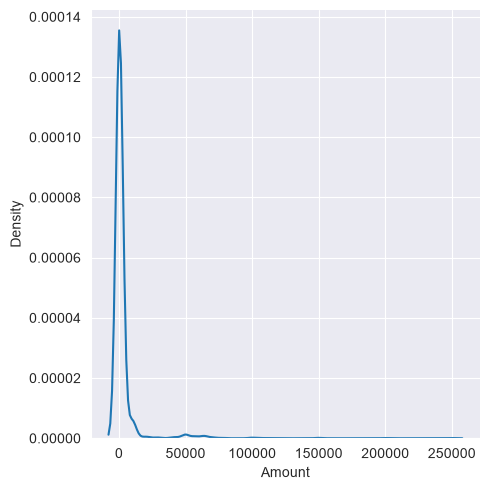

In [24]:
sns.displot(data=amount, kind = 'kde')

<Axes: xlabel='Amount', ylabel='Count'>

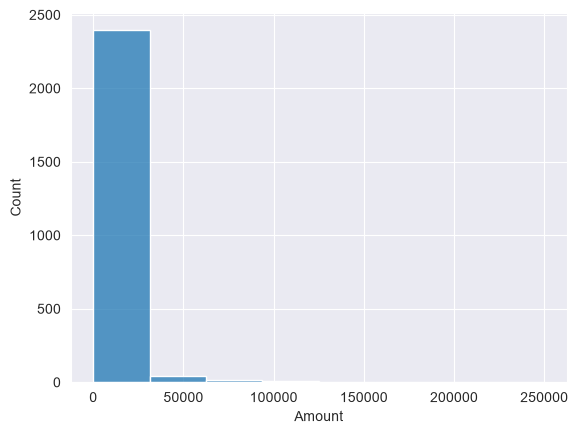

In [35]:
sns.histplot(data=amount,bins=8)

In [36]:
print(amount.skew())

9.094375738390873


<Axes: ylabel='Amount'>

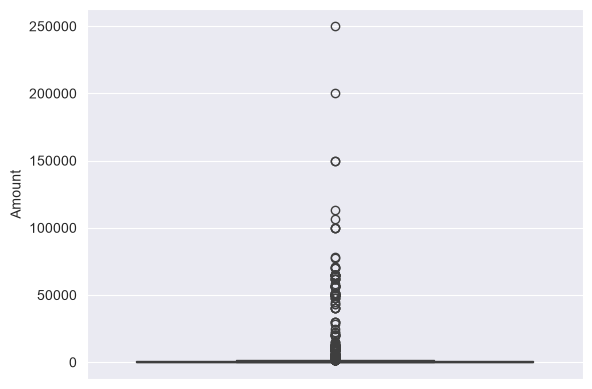

In [43]:
sns.boxplot(data = amount)

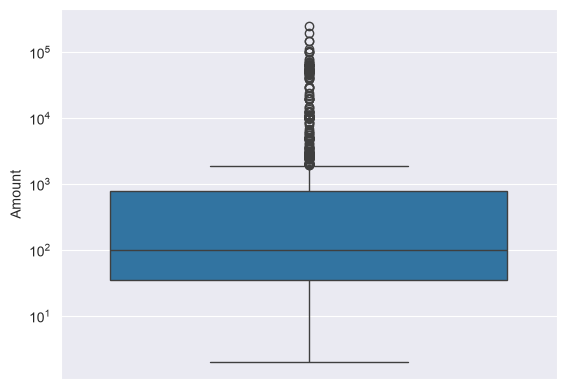

In [68]:
#using the log scale to compress large values and expand small values
sns.boxplot(data = amount)
plt.yscale('log')
plt.show()

In [69]:
print("Original skew ", amount.skew())

Original skew  9.094375738390873


In [71]:
#transform the data to adjust for the skewness in the original data
amount_log = np.log1p(amount)

In [72]:
print(amount_log.skew())

0.8471303345032415


<Axes: ylabel='Amount'>

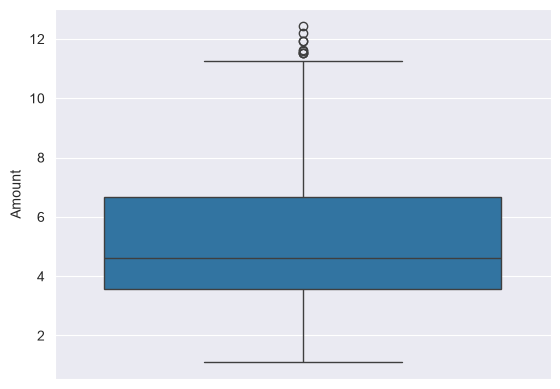

In [73]:
sns.boxplot(data=amount_log)

In [79]:
#analysing the outliers of the transformed data
low_boundary = amount_log.quantile(0.25)
upper_boundary = amount_log.quantile(0.75)
iqr = upper_boundary - low_boundary
amount_outliers = amount_log[(amount_log>upper_boundary+1.5*iqr) | (amount_log<low_boundary-1.5*iqr)]
print("Number of outliers ",amount_outliers.count())

Number of outliers  9


In [81]:
#finding the number of missing values
print(amount_log.isnull().sum())

0


In [82]:
#kurtosis
print(amount_log.kurtosis())

0.3107702001586681


In [85]:
#analysing the outlier values
outlier_rows = expenses.loc[amount_outliers.index]
print(outlier_rows[['Category','Note','Amount']])

                   Category                       Note    Amount
660         Maturity amount             SIP Redemption  113376.0
661         Maturity amount             SIP Redemption  106875.0
687           Fixed Deposit                        NaN  250000.0
688   Saving Bank account 1                        NaN  150000.0
765   Saving Bank account 1            Fund Withdrawal  100000.0
904            Share Market               Stock market  150000.0
1171   Equity Mutual Fund B                        NaN  100000.0
1225          Fixed Deposit  New FD opened for 3 years  200000.0
1710         Money transfer                        NaN  100000.0
